In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import arviz as az
az.style.use("arviz-doc")

from helper import load_params_csv
from run import run_sim

In [4]:
#helper settings
companies = {
    'IP':'Interpump Group',
    'GGG':'Graco Inc.',
    'ALFA':'Alfa Laval AB',
    'REC':'Recordati S.p.A.'
}

cmap = {
    'blue': '#0000FF',#17375E
    'yellow': '#FFF44F',
    'red': '#800000',
    'green': '#4CA877',
    'grey': '#CCD1D7',
    'gold': '#C89700'
}

In [55]:
company = 'IP'

In [57]:
params = load_params_csv('params/' + company + '_model.csv')
params['mu_tv'] = 0.02
risk_free = params['r_bar']
params['rho'] = params['r_bar'] + params['pi']
params

{'R_0': 2078.39,
 'mu_0': 0.0015,
 'mu_hat': 0.0877,
 'kappa_mu': 0.2772,
 'sigma': 0.1852,
 'eta': 0.055,
 'theta': 0.636,
 'gamma': 0.0962,
 'F_0': 12.21,
 'tau': 0.24,
 'r_bar': 0.02415,
 'pi': 0.05327,
 'rho12': 0.0,
 'mu_tv': 0.02,
 'rho': 0.07742}

In [59]:
#deal parameters
alpha = 0.6
spread = 0.05

params['r_bar'] = risk_free + spread

#time parameters
T = 5
n_steps = T * 52 + 1
y_0 = 2024
grid = np.linspace(y_0, y_0+T, n_steps)

#siulation
n_paths = 1_000
output = run_sim(
    params,
    n_steps=n_steps,
    n_paths=n_paths,
    T = T,
    alpha=alpha,
    seed=99,
    stochastic_ir = False,
    return_all = True
)

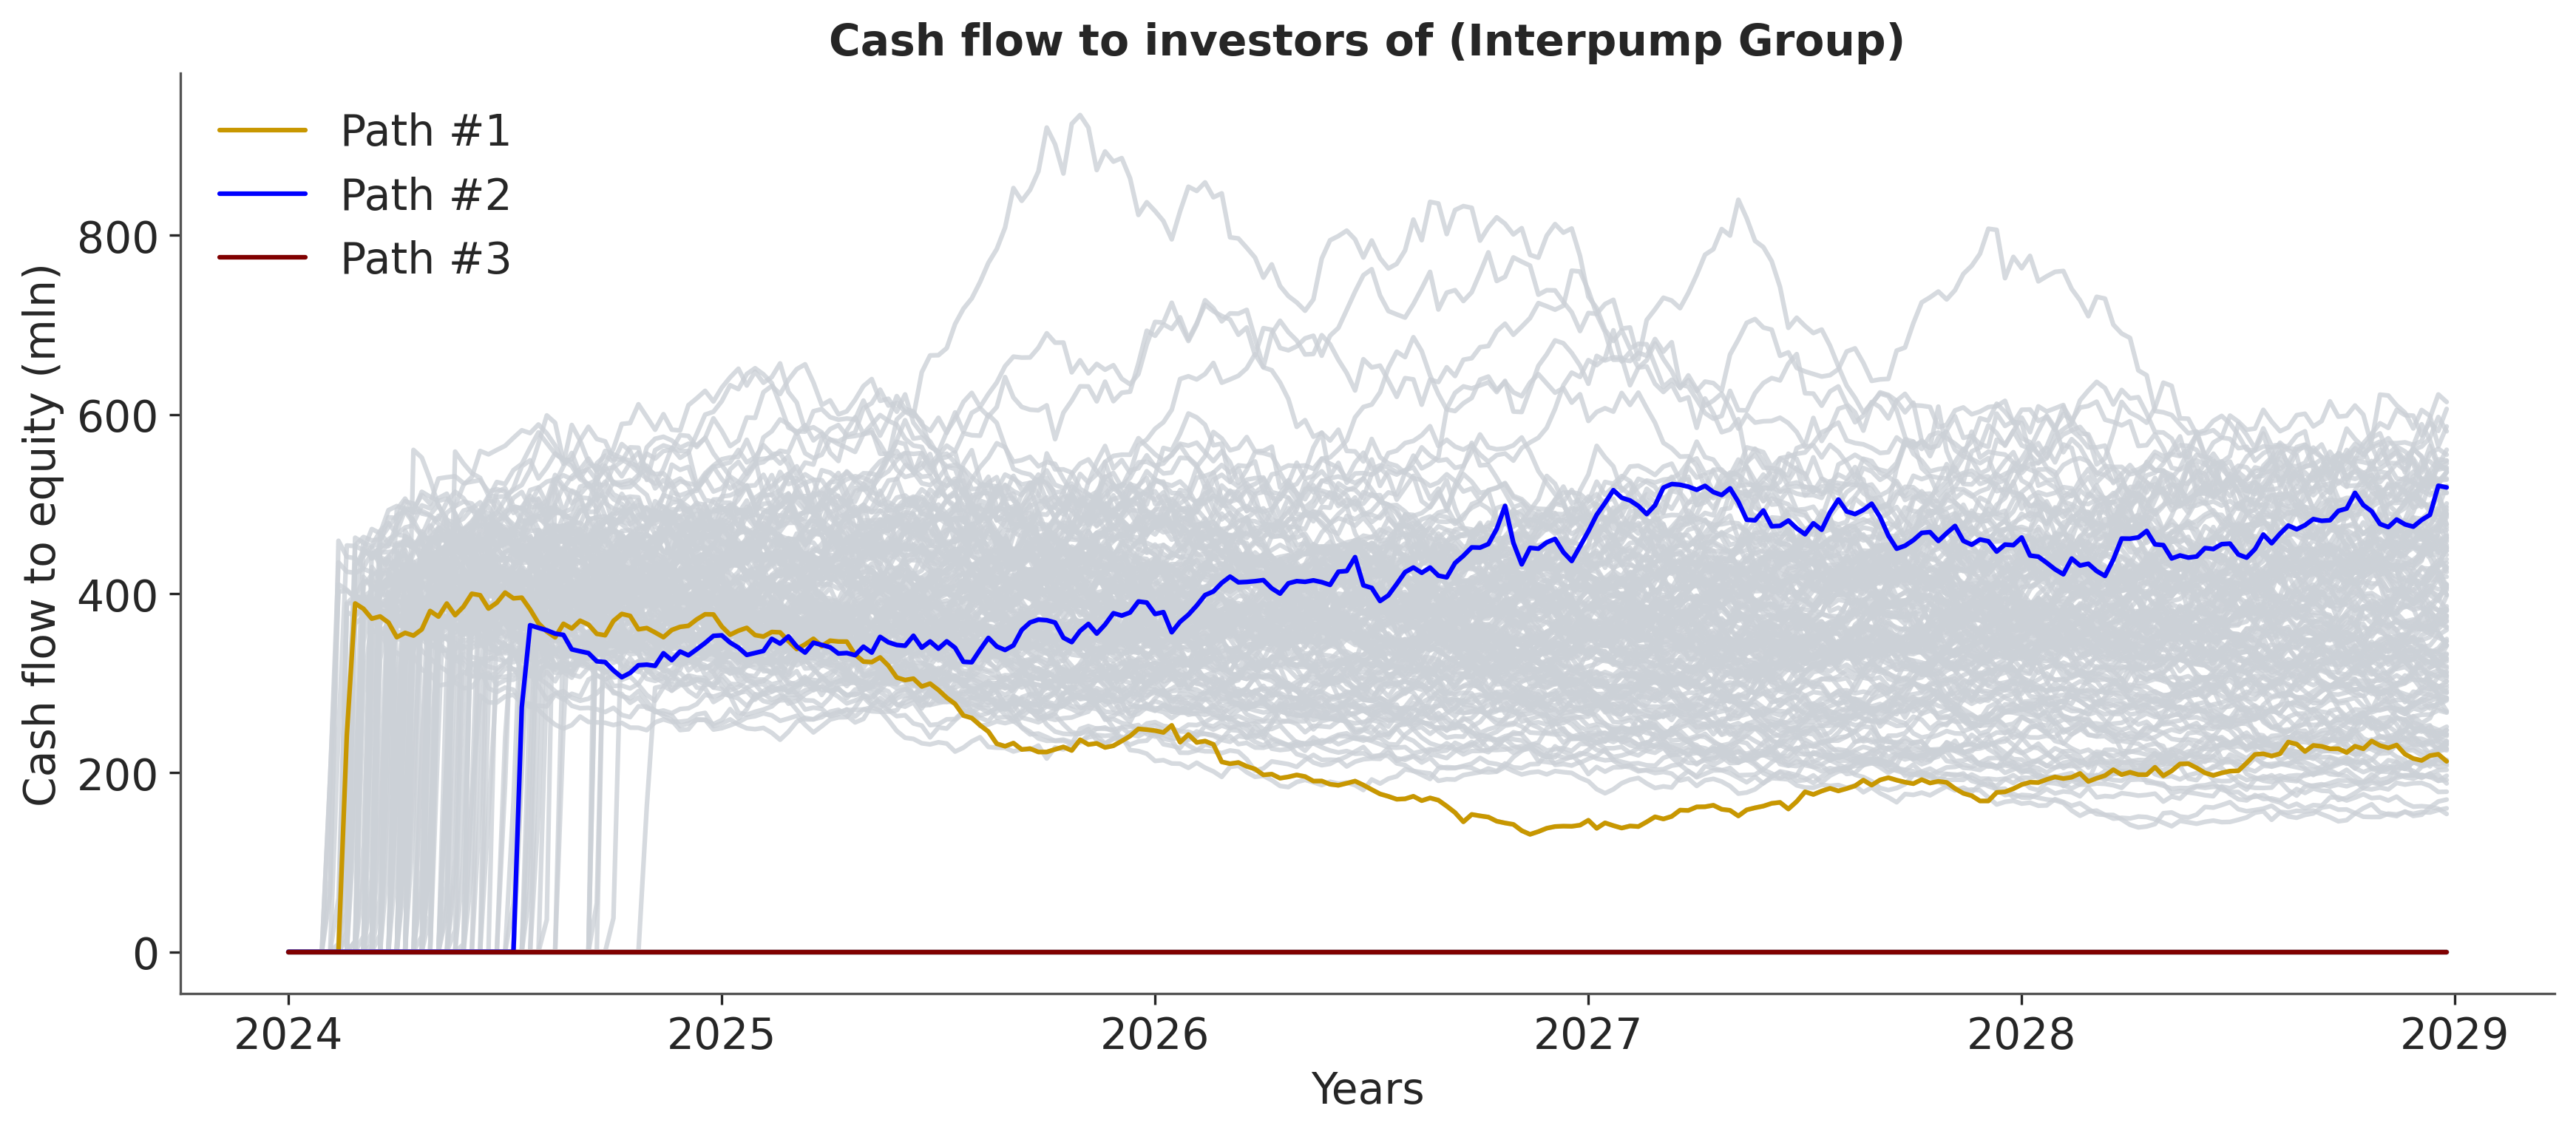

In [89]:
fig, ax = plt.subplots()
for path in output['CF'][:200]:
    ax.plot(grid[:-1], path[:-1], alpha=0.8, color=cmap['grey'])
ax.plot(grid[:-1], output['CF'][133][:-1], alpha=1, color=cmap['gold'], label='Path #1')
ax.plot(grid[:-1], output['CF'][166][:-1], alpha=1, color=cmap['blue'], label='Path #2')
ax.plot(grid[:-1], [0] * (n_steps - 1), alpha=1, color=cmap['red'], label='Path #3')

ax.set_title(f'Cash flow to investors of ({companies[company]})', fontsize=14)
ax.set_xlabel("Years")
ax.set_ylabel("Cash flow to equity (mln)")

ax.legend(loc='upper left')

plt.show()

In [53]:
default_rate = output['defaulted'][:, -1].mean()
default_rate

0.39